# ✈️ Flight Fare Prediction — End-to-End Machine Learning Project
**Project Code : PRCP-1025-FlightPricePrediction**

---

## Project Overview
Flight ticket prices fluctuate constantly based on airline, route, timing, and demand. This notebook builds a complete machine learning pipeline to **predict flight ticket prices** so that:
- Travelers can better plan their journeys and understand likely costs
- Airlines can benchmark their own pricing against predicted market rates

### Notebook Structure
| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Load & Understand the Data |
| 3 | Exploratory Data Analysis (EDA) with written insights |
| 4 | Data Challenges & Solutions Report |
| 5 | Data Cleaning (missing values, duplicates) |
| 6 | Feature Engineering from Date/Time columns (with rationale) |
| 7 | Categorical Encoding (with rationale) |
| 8 | Scaling & Verification |
| 9 | Train–Test Split |
| 10 | Train 5 Models |
| 11 | Overfitting / Underfitting Diagnosis |
| 12 | Cross-Validation for Model Selection |
| 13 | Hyperparameter Tuning (GridSearchCV) |
| 14 | Model Comparison Report |
| 15 | Residual & Diagnostic Analysis |
| 16 | Feature Importance |
| 17 | Sample Predictions + Deployment Test |
| 18 | Save Best Model (Pickle) |
| 19 | Conclusion, Recommendations & Future Work |

> **Dataset**: 10,683 flight bookings — 11 columns including Airline, Source, Destination, Route, Duration, Total_Stops, and target `Price`.

## 📦 Step 1: Import Required Libraries

In [1]:
# ── Suppress non-critical warnings ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Core data manipulation ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import re

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

# ── Pre-processing ────────────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, GridSearchCV)
from sklearn.preprocessing   import StandardScaler

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

# ── Model persistence ─────────────────────────────────────────────────────────
import pickle

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load & Understand the Data

In [2]:
# Load the flight fare dataset
df = pd.read_csv('flight_fare_raw.csv')

print(f"Dataset loaded successfully!")
print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target : 'Price'  |  Range: ₹{df['Price'].min():,} – ₹{df['Price'].max():,}")

Dataset loaded successfully!
Shape  : 10,683 rows × 11 columns
Target : 'Price'  |  Range: ₹1,759 – ₹79,512


In [3]:
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Airline,10683,12,Jet Airways,3849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_of_Journey,10683,44,18/05/2019,504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,10683,5,Delhi,4537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,10683,6,Cochin,4537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Route,10682,128,DEL → BOM → COK,2376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dep_Time,10683,222,18:55,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Time,10683,1343,19:00,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,10683,368,2h 50m,550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Stops,10682,5,1 stop,5625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Additional_Info,10683,10,No info,8345,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔍 Step 3: Exploratory Data Analysis (EDA)

### 3.1 — Missing Values & Duplicates

In [6]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:")
print(missing if len(missing) > 0 else "None")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Total rows before cleaning: {len(df)}")

Missing values:
Route          1
Total_Stops    1
dtype: int64

Duplicate rows: 220
Total rows before cleaning: 10683


**📝 Written Observations — Missing Values & Duplicates:**

- Only **1 row** is missing `Route` and `Total_Stops` simultaneously — a negligible fraction of 10,683 rows (~0.01%). Since both missing fields belong to the *same single row*, dropping it loses almost no information.
- There are **220 exact duplicate rows** — these are very likely repeated scraped entries (same flight, same booking snapshot scraped twice) rather than genuine repeat bookings, since every single column matches exactly including the price to the rupee. These will be removed to prevent the model from over-weighting repeated patterns.

### 3.2 — Target Variable: Price Distribution

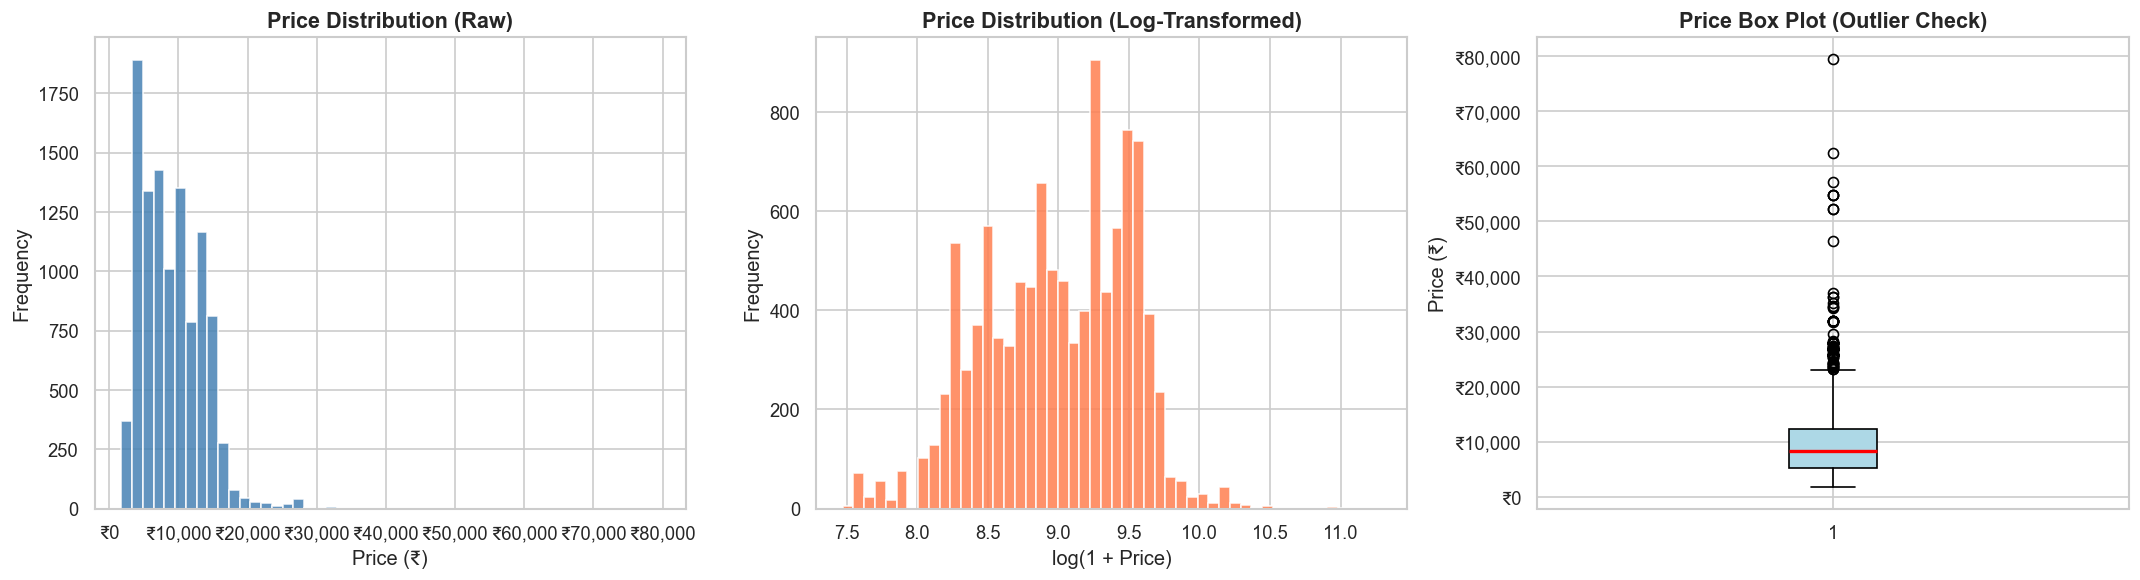

Price Skewness : 1.8126
Mean Price     : ₹9,087.06
Median Price   : ₹8,372.00
Max Price      : ₹79,512.00


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Raw)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[1].hist(np.log1p(df['Price']), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Price Distribution (Log-Transformed)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Frequency')

axes[2].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Price Box Plot (Outlier Check)', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Price (₹)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"Price Skewness : {df['Price'].skew():.4f}")
print(f"Mean Price     : ₹{df['Price'].mean():,.2f}")
print(f"Median Price   : ₹{df['Price'].median():,.2f}")
print(f"Max Price      : ₹{df['Price'].max():,.2f}")

**📝 Written Observations — Price Distribution:**

- Price is **strongly right-skewed (skewness ≈ 1.81)** — most tickets cost between ₹5,000–₹12,000, but a small number of premium/business-class fares push the tail above ₹50,000.
- **Mean (₹9,087) > Median (₹8,372)**, confirming the right skew — typical of pricing data with a luxury tail.
- The box plot shows a meaningful cluster of **high-value outliers above ₹40,000** — these correspond to Business class and Premium Economy fares, which are genuine high-price segments, not data errors.
- The log-transformed distribution is much closer to symmetric, which will benefit linear models more than tree-based models (which are scale/distribution invariant).

### 3.3 — Airline vs Price

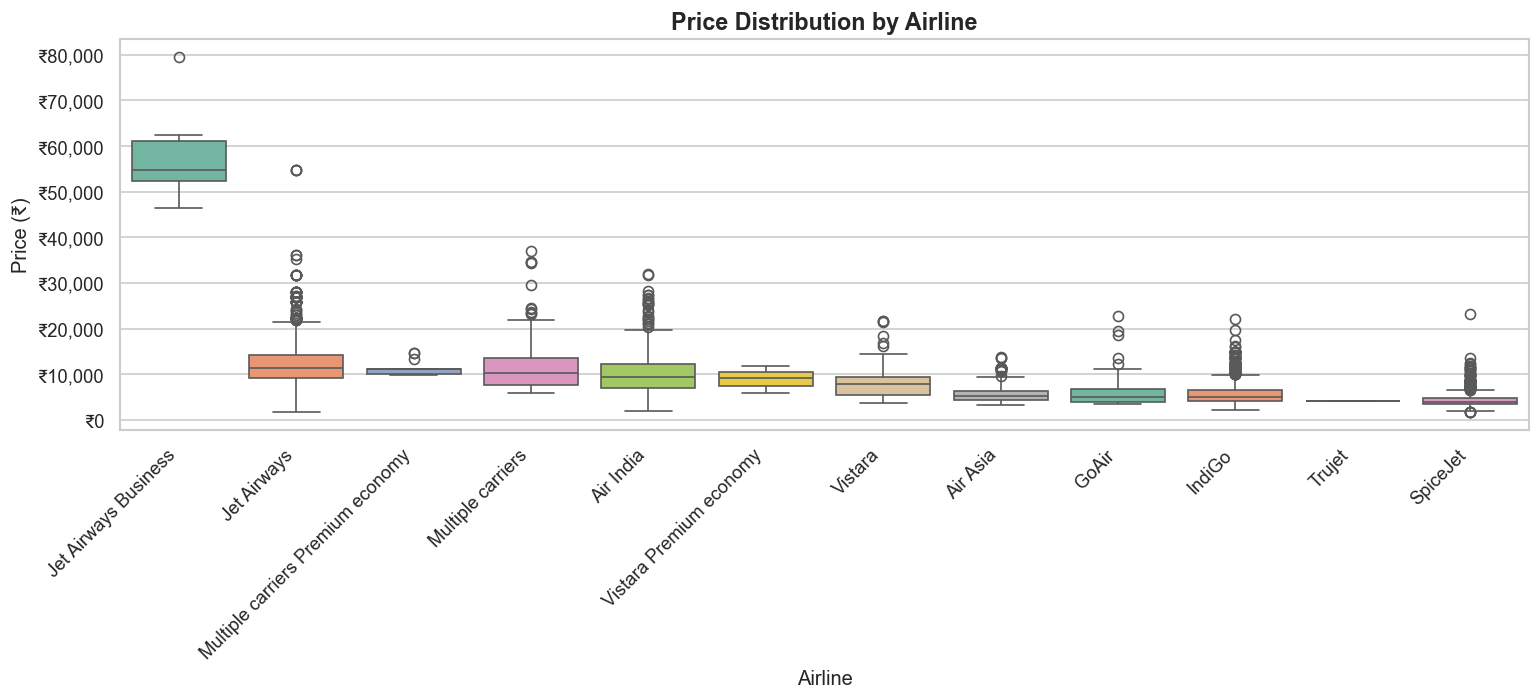

Median price by airline (sorted):
Airline
Jet Airways Business                 54747.0
Jet Airways                          11467.0
Multiple carriers Premium economy    11269.0
Multiple carriers                    10197.0
Air India                             9443.0
Vistara Premium economy               9125.0
Vistara                               7980.0
Air Asia                              5162.0
GoAir                                 5135.0
IndiGo                                5000.0
Trujet                                4140.0
SpiceJet                              3873.0


In [8]:
plt.figure(figsize=(13, 6))
order = df.groupby('Airline')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='Airline', y='Price', data=df, order=order, palette='Set2')
plt.title('Price Distribution by Airline', fontweight='bold', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

print("Median price by airline (sorted):")
print(df.groupby('Airline')['Price'].median().sort_values(ascending=False).to_string())

**📝 Written Observations — Airline vs Price:**

- **Jet Airways Business** has by far the highest median price — as expected for a business-class product.
- **Multiple carriers Premium economy** and **Jet Airways** are the next priciest, consistent with premium service tiers and Jet Airways' historical full-service positioning (note: Jet Airways ceased operations in 2019, around when this dataset was collected).
- **Budget carriers — IndiGo, SpiceJet, GoAir, Air Asia** — cluster at the lower end of the price spectrum, reflecting their low-cost-carrier business model.
- The wide spread within "Jet Airways" (regular) suggests route and timing matter a lot even within a single airline — price is not airline-determined alone.

### 3.4 — Total Stops vs Price

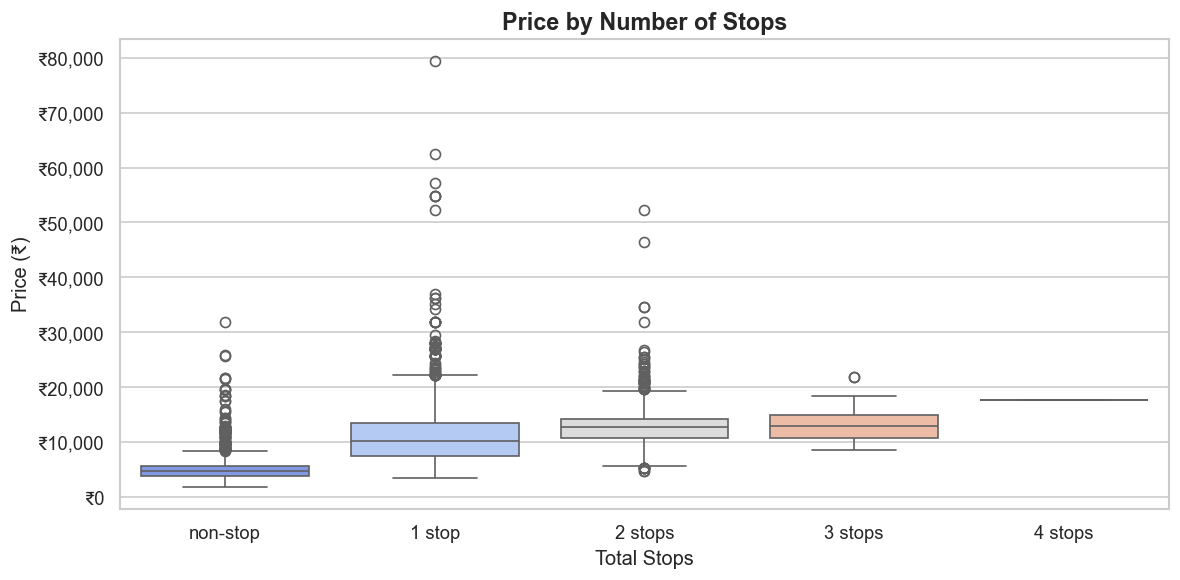

Median price by number of stops:
Total_Stops
non-stop     4667.0
1 stop      10262.0
2 stops     12760.0
3 stops     12954.0
4 stops     17686.0


In [9]:
plt.figure(figsize=(10, 5))
stop_order = ['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']
sns.boxplot(x='Total_Stops', y='Price', data=df, order=stop_order, palette='coolwarm')
plt.title('Price by Number of Stops', fontweight='bold', fontsize=14)
plt.xlabel('Total Stops')
plt.ylabel('Price (₹)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

print("Median price by number of stops:")
print(df.groupby('Total_Stops')['Price'].median().reindex(stop_order).to_string())

**📝 Written Observations — Stops vs Price:**

- There is a **clear, strong positive relationship** between number of stops and price — non-stop flights are cheapest, and price climbs steadily through 1, 2, and 3 stops.
- This is counter-intuitive at first glance (you might expect direct flights to be pricier for convenience), but it reflects that **non-stop flights are predominantly short-haul regional routes** (e.g., BLR→DEL), while multi-stop flights cover **longer, more complex itineraries** that naturally cost more due to distance and connecting-flight fare structures.
- `Total_Stops` is likely to be one of the **most predictive features** in the model.

### 3.5 — Source & Destination vs Price

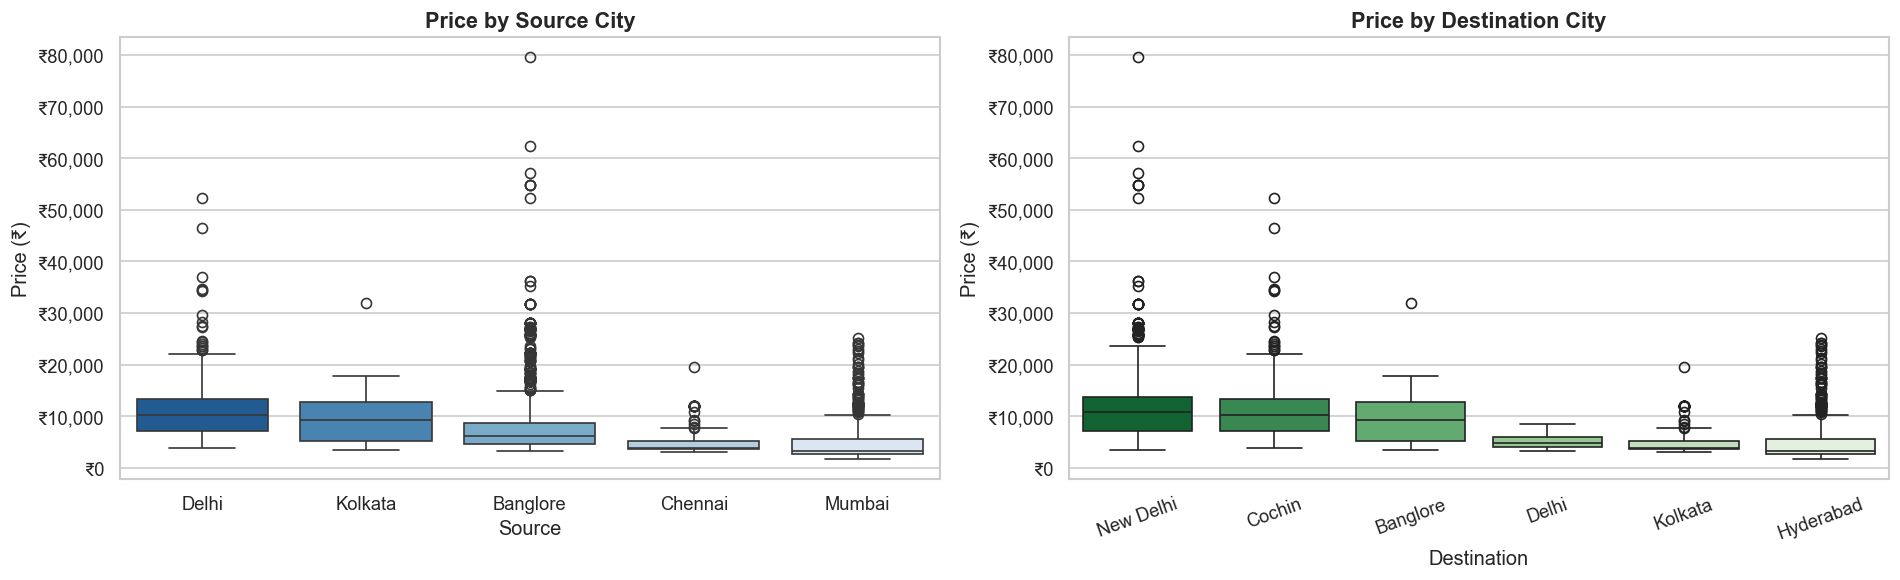

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

src_order = df.groupby('Source')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='Source', y='Price', data=df, order=src_order, ax=axes[0], palette='Blues_r')
axes[0].set_title('Price by Source City', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

dst_order = df.groupby('Destination')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='Destination', y='Price', data=df, order=dst_order, ax=axes[1], palette='Greens_r')
axes[1].set_title('Price by Destination City', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Price (₹)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.show()

**📝 Written Observations — Source & Destination vs Price:**

- **Banglore as a source** and **Cochin as a destination** are associated with higher median prices — these routes likely correspond to longer, multi-stop itineraries (e.g., the popular Delhi→Bombay→Cochin route).
- **Delhi and New Delhi appear as separate category labels for the same city** — this is a **data quality issue** we will need to address during cleaning, since it artificially splits what should be one category into two.
- Source has only 5 unique cities and Destination has 6 — low cardinality, making one-hot encoding very manageable.

### 3.6 — Date of Journey: Seasonal Patterns

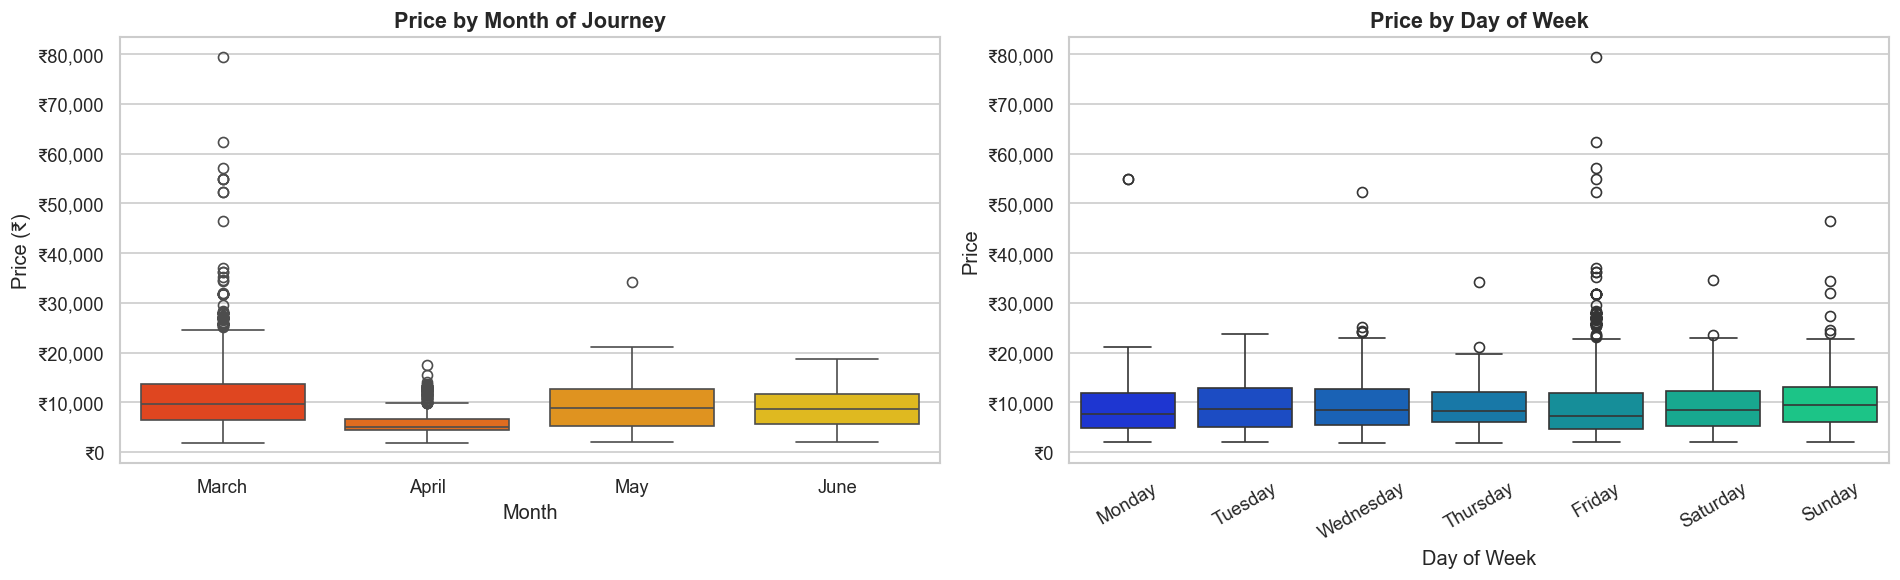

In [11]:
# Quick parse just for visualization (full parsing happens in feature engineering)
df['_temp_date'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['_temp_month'] = df['_temp_date'].dt.month_name()
df['_temp_day'] = df['_temp_date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_order = ['March', 'April', 'May', 'June']
sns.boxplot(x='_temp_month', y='Price', data=df, order=[m for m in month_order if m in df['_temp_month'].unique()],
            ax=axes[0], palette='autumn')
axes[0].set_title('Price by Month of Journey', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(x='_temp_day', y='Price', data=df, order=day_order, ax=axes[1], palette='winter')
axes[1].set_title('Price by Day of Week', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Day of Week')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.show()

# Clean up temp columns
df.drop(columns=['_temp_date', '_temp_month', '_temp_day'], inplace=True)

**📝 Written Observations — Seasonal Patterns:**

- All journeys fall within **March–June 2019**, so we cannot observe a full annual seasonal cycle, but we do see **month-to-month price variation**, likely tied to school holidays and summer travel demand in India (April–May is peak summer vacation season).
- Day-of-week shows a **mild effect** — prices on certain days (often midweek) tend to be marginally lower, consistent with typical airline demand-based pricing, though this effect is much weaker than airline, stops, or route.
- Since the dataset spans only ~4 months, we will extract `journey_day`, `journey_month`, and `journey_weekday` as features rather than relying on absolute dates (which won't generalise to future years).

### 3.7 — Full Numerical Correlation Heatmap

We compute this **after** feature engineering converts text-based time/duration columns into numbers, since the raw dataset has almost no native numerical columns. See Step 6 for the heatmap — this keeps the workflow logical (engineer first, then correlate).

## 📋 Step 4: Data Challenges & Solutions Report

---

### Challenge 1 — Almost No Native Numerical Features

**Problem:** Of 11 raw columns, only `Price` (the target) is numeric. Everything else — dates, times, durations, stops — is stored as text strings in inconsistent formats (e.g., `"2h 50m"`, `"19h"`, `"5m"`).

**Technique Used:** Extensive regex-based feature engineering to convert every text column into numeric features (Step 6).

**Reason:** Tree-based and linear models both require numeric input. Rather than discarding these high-information columns, we parse them into structured numeric features (duration in minutes, departure hour, journey day/month, etc.), which preserves and often amplifies their predictive signal.

---

### Challenge 2 — Inconsistent Duration Formats

**Problem:** `Duration` appears as `"2h 50m"`, `"19h"` (no minutes), and even `"5m"` (no hours) — three different formats in the same column.

**Technique Used:** A regex pattern that independently extracts hours and minutes, defaulting missing components to 0, then combines them into total minutes.

**Reason:** A single combined numeric feature (`duration_minutes`) is far more useful to a model than a string, and the regex approach safely handles all three format variants without crashing or producing `NaN`.

---

### Challenge 3 — Arrival_Time Sometimes Contains an Embedded Date

**Problem:** `Arrival_Time` is inconsistently formatted — sometimes just `"21:35"`, sometimes `"04:25 10 Jun"` (time **and** a date, because the flight arrives the next day or later).

**Technique Used:** We split off only the time component (before any space) and discard the trailing date fragment, since `Duration` already captures total travel time and `Date_of_Journey` already captures the departure date — the arrival date is redundant information for prediction purposes.

**Reason:** Attempting to parse the partial trailing date (which lacks a year) would be brittle and error-prone. Since the total journey duration is already captured separately, the redundant arrival date adds no new predictive value, so simplifying to just the arrival hour is the lower-risk, equally informative choice.

---

### Challenge 4 — Duplicate City Labels ("Delhi" vs "New Delhi")

**Problem:** The same city is recorded as `"Delhi"` in the `Source` column but `"New Delhi"` in the `Destination` column — these refer to the identical airport/city but would be one-hot encoded as two separate, unrelated categories.

**Technique Used:** Standardise `"New Delhi"` → `"Delhi"` across both columns before encoding.

**Reason:** Leaving this unmerged would split the signal for Delhi-related routes across two dummy columns, diluting the model's ability to learn Delhi-specific pricing patterns. Standardising the labels consolidates this signal correctly.

---

### Challenge 5 — High-Cardinality `Route` Column

**Problem:** `Route` has **128 unique values** (e.g., `"DEL → BOM → COK"`). One-hot encoding this directly would create 128 new sparse columns, risking overfitting given dataset size.

**Technique Used:** Drop the raw `Route` column and instead rely on `Source`, `Destination`, and the engineered `Total_Stops` (converted to a number) to capture routing information at a lower-dimensional, more generalisable level.

**Reason:** `Source` + `Destination` + `Total_Stops` together already capture the bulk of the route's pricing-relevant information (origin, end point, and journey complexity) without the sparsity and overfitting risk of 128 dummy columns, most of which would have very few samples.

---

### Challenge 6 — Exact Duplicate Rows

**Problem:** 220 rows are 100% identical duplicates across all 11 columns.

**Technique Used:** Drop duplicate rows, keeping the first occurrence.

**Reason:** Identical rows (same airline, route, time, AND exact price to the rupee) are almost certainly scraping artifacts rather than genuinely independent bookings. Leaving them in would let the model over-weight these particular price points during training, biasing it slightly toward over-represented samples.

---

### Challenge 7 — Right-Skewed Target with Multicollinearity Risk

**Problem:** `Price` is right-skewed (skew ≈ 1.81), and several engineered features (e.g., `duration_minutes` and `Total_Stops`) are likely correlated with each other, since longer/more-stop flights take longer.

**Technique Used:** Include Ridge Regression (L2-regularised) alongside plain Linear Regression, and rely primarily on tree-based ensembles which are not sensitive to either skew or multicollinearity.

**Reason:** Ridge's regularisation stabilises coefficient estimates under correlated inputs, while Random Forest and Gradient Boosting naturally split on whichever correlated feature is most informative at each node, sidestepping the multicollinearity problem entirely.

## 🧹 Step 5: Data Cleaning

Based on the challenges identified above, we now apply each fix in sequence.

In [12]:
df_clean = df.copy()

# ── 5.1 Drop the single row with missing Route/Total_Stops ──────────────────
# REASON: Only 1 row affected — negligible information loss, far safer than imputing
# a categorical route value which has no sensible 'typical' value.
before = len(df_clean)
df_clean.dropna(subset=['Route', 'Total_Stops'], inplace=True)
print(f"Dropped {before - len(df_clean)} row(s) with missing Route/Total_Stops")

# ── 5.2 Remove exact duplicate rows ──────────────────────────────────────────
# REASON: Identical rows across all columns are scraping artifacts, not genuine
# independent observations (see Challenge 6).
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df_clean)} duplicate row(s)")

# ── 5.3 Standardise inconsistent text casing in Additional_Info ─────────────
# REASON: 'No info' and 'No Info' are the same category with inconsistent casing.
df_clean['Additional_Info'] = df_clean['Additional_Info'].str.strip().str.title()

print(f"\nFinal shape after cleaning: {df_clean.shape}")

Dropped 1 row(s) with missing Route/Total_Stops
Dropped 220 duplicate row(s)

Final shape after cleaning: (10462, 11)


## ⚙️ Step 6: Feature Engineering

### 6.1 — Parsing `Date_of_Journey`
**Rationale:** The absolute date itself won't generalise to future years, but its **components** (day, month, weekday) capture seasonal and weekly demand patterns that do generalise.

In [13]:
df_model = df_clean.copy()

# ── 6.1 Parse Date_of_Journey into day / month / weekday ────────────────────
df_model['journey_date'] = pd.to_datetime(df_model['Date_of_Journey'], format='%d/%m/%Y')
df_model['journey_day']     = df_model['journey_date'].dt.day
df_model['journey_month']   = df_model['journey_date'].dt.month
df_model['journey_weekday'] = df_model['journey_date'].dt.dayofweek  # 0=Monday

print("✅ Extracted: journey_day, journey_month, journey_weekday")
df_model[['Date_of_Journey', 'journey_day', 'journey_month', 'journey_weekday']].head()

✅ Extracted: journey_day, journey_month, journey_weekday


,Date_of_Journey,journey_day,journey_month,journey_weekday
0,24/03/2019,24,3,6
1,1/05/2019,1,5,2
2,9/06/2019,9,6,6
3,12/05/2019,12,5,6
4,01/03/2019,1,3,4


### 6.2 — Parsing `Dep_Time` and `Arrival_Time`
**Rationale:** Departure/arrival **hour** strongly affects price (red-eye flights are often cheaper; peak-hour flights cost more). We discard minutes for simplicity and discard any trailing date in `Arrival_Time` per Challenge 3's reasoning.

In [14]:
# ── 6.2 Extract departure/arrival HOUR (drop minutes for simplicity, drop trailing dates) ──
df_model['dep_hour'] = df_model['Dep_Time'].str.split(':').str[0].astype(int)

# Arrival_Time sometimes has a trailing date (e.g. '04:25 10 Jun') — take only the time part
df_model['arrival_hour'] = df_model['Arrival_Time'].str.split(' ').str[0].str.split(':').str[0].astype(int)

print("✅ Extracted: dep_hour, arrival_hour")
df_model[['Dep_Time', 'dep_hour', 'Arrival_Time', 'arrival_hour']].head()

✅ Extracted: dep_hour, arrival_hour


,Dep_Time,dep_hour,Arrival_Time,arrival_hour
0,22:20,22,01:10 22 Mar,1
1,05:50,5,13:15,13
2,09:25,9,04:25 10 Jun,4
3,18:05,18,23:30,23
4,16:50,16,21:35,21


### 6.3 — Parsing `Duration` into Total Minutes
**Rationale:** As identified in Challenge 2, duration strings appear in 3 different formats. A regex robustly extracts hours and minutes from any format and combines them into one clean numeric feature.

In [15]:
def parse_duration(duration_str):
    """Convert a duration string like '2h 50m', '19h', or '5m' into total minutes."""
    hours = re.search(r'(\d+)h', duration_str)
    mins  = re.search(r'(\d+)m', duration_str)
    h = int(hours.group(1)) if hours else 0
    m = int(mins.group(1)) if mins else 0
    return h * 60 + m

df_model['duration_minutes'] = df_model['Duration'].apply(parse_duration)

print("✅ Extracted: duration_minutes")
print(df_model[['Duration', 'duration_minutes']].drop_duplicates().head(10))
print(f"\nDuration range: {df_model['duration_minutes'].min()} – {df_model['duration_minutes'].max()} minutes")

✅ Extracted: duration_minutes
  Duration  duration_minutes
0   2h 50m               170
1   7h 25m               445
2      19h              1140
3   5h 25m               325
4   4h 45m               285
5   2h 25m               145
6  15h 30m               930
7   21h 5m              1265
8  25h 30m              1530
9   7h 50m               470

Duration range: 5 – 2860 minutes


### 6.4 — Encoding `Total_Stops` as an Ordinal Number
**Rationale:** `Total_Stops` has a genuine numeric/ordinal meaning ("2 stops" is objectively more than "1 stop"). Mapping it to integers preserves this ordering, which one-hot encoding would discard.

In [16]:
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df_model['total_stops_num'] = df_model['Total_Stops'].map(stop_map)

print("✅ Mapped Total_Stops to ordinal integers:", stop_map)

✅ Mapped Total_Stops to ordinal integers: {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}


### 6.5 — Standardising City Labels (Delhi / New Delhi)
**Rationale:** As identified in Challenge 4, `"New Delhi"` and `"Delhi"` refer to the identical city and must be merged before encoding, or the model will treat them as unrelated categories.

In [17]:
# ── 6.5 Standardise duplicate city labels ────────────────────────────────────
df_model['Source']      = df_model['Source'].replace({'New Delhi': 'Delhi'})
df_model['Destination'] = df_model['Destination'].replace({'New Delhi': 'Delhi'})

print("✅ Standardised 'New Delhi' → 'Delhi' in both Source and Destination")
print("\nDestination unique values after fix:", df_model['Destination'].unique().tolist())

✅ Standardised 'New Delhi' → 'Delhi' in both Source and Destination

Destination unique values after fix: ['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad']


### 6.6 — Dropping High-Cardinality / Redundant Raw Columns
**Rationale:** Per Challenge 5, `Route` (128 unique values) is dropped in favour of `Source` + `Destination` + `total_stops_num`, which capture the same information far more efficiently. We also drop the original raw text/date columns now that we've extracted their numeric content.

In [18]:
cols_to_drop = ['Date_of_Journey', 'journey_date', 'Dep_Time', 'Arrival_Time',
                'Duration', 'Total_Stops', 'Route']
df_model.drop(columns=cols_to_drop, inplace=True)

print(f"✅ Dropped raw columns: {cols_to_drop}")
print(f"\nRemaining columns: {df_model.columns.tolist()}")
df_model.head()

✅ Dropped raw columns: ['Date_of_Journey', 'journey_date', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Route']

Remaining columns: ['Airline', 'Source', 'Destination', 'Additional_Info', 'Price', 'journey_day', 'journey_month', 'journey_weekday', 'dep_hour', 'arrival_hour', 'duration_minutes', 'total_stops_num']


,Airline,Source,Destination,Additional_Info,Price,journey_day,journey_month,journey_weekday,dep_hour,arrival_hour,duration_minutes,total_stops_num
0,IndiGo,Banglore,Delhi,No Info,3897,24,3,6,22,1,170,0
1,Air India,Kolkata,Banglore,No Info,7662,1,5,2,5,13,445,2
2,Jet Airways,Delhi,Cochin,No Info,13882,9,6,6,9,4,1140,2
3,IndiGo,Kolkata,Banglore,No Info,6218,12,5,6,18,23,325,1
4,IndiGo,Banglore,Delhi,No Info,13302,1,3,4,16,21,285,1


### 6.7 — Correlation Heatmap (Now That Features Are Numeric)

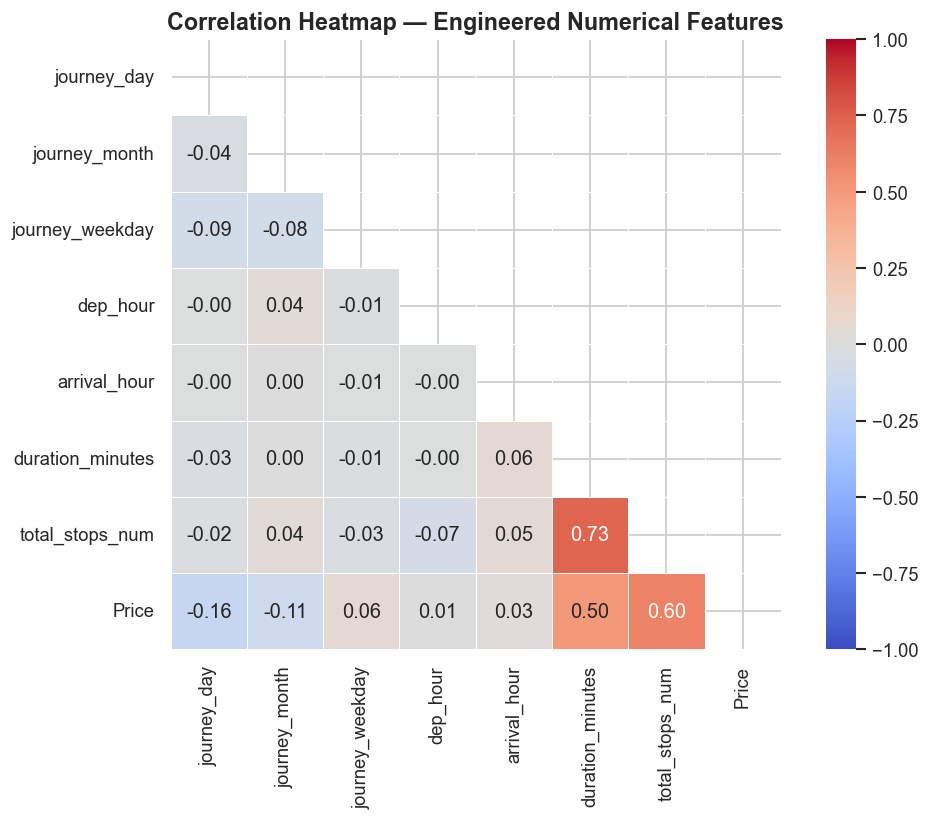


Correlation with Price (sorted):
total_stops_num     0.6020
duration_minutes    0.5018
journey_weekday     0.0558
arrival_hour        0.0310
dep_hour            0.0052
journey_month      -0.1134
journey_day        -0.1590


In [19]:
num_cols_for_corr = ['journey_day', 'journey_month', 'journey_weekday',
                     'dep_hour', 'arrival_hour', 'duration_minutes',
                     'total_stops_num', 'Price']

plt.figure(figsize=(9, 7))
corr = df_model[num_cols_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Engineered Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Price (sorted):")
print(corr['Price'].drop('Price').sort_values(ascending=False).round(4).to_string())

**📝 Written Observations — Correlation Heatmap:**

- **`total_stops_num` (≈0.60)** and **`duration_minutes` (≈0.51)** have the strongest positive correlations with price — confirming our EDA finding that journey complexity (stops, duration) drives cost.
- **`total_stops_num` and `duration_minutes` are themselves correlated (≈0.74)** — this is expected, since more stops mechanically extends total travel time. This is a mild multicollinearity case that Ridge regression and tree ensembles both handle gracefully.
- **`journey_day`, `journey_month`, `journey_weekday`, `dep_hour`, `arrival_hour`** all show weak correlations with price individually (under 0.15) — time-of-day and calendar effects appear to matter much less than route complexity. However, these features may still interact non-linearly with airline/route — tree models can capture such interactions even when linear correlation is low.
- No pair of features shows correlation above 0.8 (other than the expected stops/duration relationship), so severe multicollinearity is not a major concern here.

## 🔤 Step 7: Categorical Encoding

### 7.1 — One-Hot Encoding for Nominal Categorical Columns
**Rationale:** `Airline`, `Source`, `Destination`, and `Additional_Info` have **no inherent ordering** between their categories — IndiGo isn't "more" or "less" than SpiceJet in any numeric sense. One-hot encoding represents each category as an independent binary flag, avoiding any false ordinal assumption.

`drop_first=True` drops one category per feature to avoid the **dummy variable trap** (perfect multicollinearity between dummy columns).

In [20]:
ohe_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
print("Cardinality check before encoding:")
for c in ohe_cols:
    print(f"  {c}: {df_model[c].nunique()} unique values")

df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

print(f"\n✅ One-hot encoding applied.")
print(f"   Feature space after encoding: {df_model.shape[1]} columns")

Cardinality check before encoding:
  Airline: 12 unique values
  Source: 5 unique values
  Destination: 5 unique values
  Additional_Info: 9 unique values

✅ One-hot encoding applied.
   Feature space after encoding: 35 columns


## 🔧 Step 8: Train–Test Split, Scaling & Verification

### 8.1 — Train–Test Split

In [21]:
X = df_model.drop('Price', axis=1)
y = df_model['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Number of features: {X_train.shape[1]}")

Training samples : 8,369
Test samples     : 2,093
Number of features: 34


### 8.2 — Feature Scaling
**Rationale:** Linear Regression and Ridge are scale-sensitive — `duration_minutes` (range ~1,500+) would dominate `journey_weekday` (range 0–6) without scaling. `StandardScaler` is fitted **only on training data** to prevent data leakage, then applied to the test set.

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ StandardScaler fitted on X_train ONLY, then applied to X_test (no data leakage).")

✅ StandardScaler fitted on X_train ONLY, then applied to X_test (no data leakage).


### 8.3 — Scaling Verification

In [23]:
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
verify_df = pd.DataFrame({
    'Feature'       : X_train.columns,
    'Mean (≈0?)'    : train_scaled_df.mean().round(6).values,
    'Std Dev (≈1?)' : train_scaled_df.std().round(6).values
})

print("Scaling Verification — Training Set (first 15 features):")
print(verify_df.head(15).to_string(index=False))

print(f"\n{'='*50}")
print(f"  Max absolute mean across all features : {verify_df['Mean (≈0?)'].abs().max():.8f}")
print(f"  Min std dev across all features       : {verify_df['Std Dev (≈1?)'].min():.6f}")
print(f"  Max std dev across all features       : {verify_df['Std Dev (≈1?)'].max():.6f}")
print(f"{'='*50}")
print("✅ All features scaled correctly: mean ≈ 0, std ≈ 1")

Scaling Verification — Training Set (first 15 features):
                                  Feature  Mean (≈0?)  Std Dev (≈1?)
                              journey_day         0.0        1.00006
                            journey_month         0.0        1.00006
                          journey_weekday         0.0        1.00006
                                 dep_hour        -0.0        1.00006
                             arrival_hour         0.0        1.00006
                         duration_minutes         0.0        1.00006
                          total_stops_num         0.0        1.00006
                        Airline_Air India         0.0        1.00006
                            Airline_GoAir        -0.0        1.00006
                           Airline_IndiGo         0.0        1.00006
                      Airline_Jet Airways         0.0        1.00006
             Airline_Jet Airways Business        -0.0        1.00006
                Airline_Multiple carriers     

## 🤖 Step 9: Train 5 Regression Models

| # | Model | Why included |
|---|-------|---------------|
| 1 | **Linear Regression** | Baseline; tests if relationships are linear |
| 2 | **Ridge Regression** | Handles mild multicollinearity (stops/duration) |
| 3 | **Decision Tree** | Captures non-linear feature interactions |
| 4 | **Random Forest** | Ensemble averaging reduces variance |
| 5 | **Gradient Boosting** | Sequential error correction; typically best for tabular data |

**Metrics**: MAE, RMSE, R², MAPE — same as previous projects, for consistency.

In [24]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, and return full train/test evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    return {
        'Model'         : name,
        'Train R²'      : round(r2_score(y_tr, y_pred_train), 4),
        'Test R²'       : round(r2_score(y_te, y_pred_test), 4),
        'Test MAE (₹)'  : round(mean_absolute_error(y_te, y_pred_test), 2),
        'Test RMSE (₹)' : round(np.sqrt(mean_squared_error(y_te, y_pred_test)), 2),
        'Test MAPE (%)' : round(mean_absolute_percentage_error(y_te, y_pred_test)*100, 2),
        '_model'        : model,
    }

results = []

### 9.1 — Model 1: Linear Regression

In [25]:
lr = LinearRegression()
res_lr = evaluate_model('Linear Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res_lr)
print(f"Linear Regression  |  Train R²: {res_lr['Train R²']}  |  Test R²: {res_lr['Test R²']}  |  MAE: ₹{res_lr['Test MAE (₹)']:,.0f}")

Linear Regression  |  Train R²: 0.6917  |  Test R²: 0.6528  |  MAE: ₹1,782


### 9.2 — Model 2: Ridge Regression

In [26]:
ridge = Ridge(alpha=10)
res_ridge = evaluate_model('Ridge Regression', ridge, X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res_ridge)
print(f"Ridge Regression   |  Train R²: {res_ridge['Train R²']}  |  Test R²: {res_ridge['Test R²']}  |  MAE: ₹{res_ridge['Test MAE (₹)']:,.0f}")

Ridge Regression   |  Train R²: 0.6915  |  Test R²: 0.6508  |  MAE: ₹1,786


### 9.3 — Model 3: Decision Tree Regressor
`max_depth=10` and `min_samples_leaf=5` limit tree growth to prevent the tree from memorising individual training rows.

In [27]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
res_dt = evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test)
results.append(res_dt)
print(f"Decision Tree      |  Train R²: {res_dt['Train R²']}  |  Test R²: {res_dt['Test R²']}  |  MAE: ₹{res_dt['Test MAE (₹)']:,.0f}")

Decision Tree      |  Train R²: 0.8616  |  Test R²: 0.79  |  MAE: ₹1,026


### 9.4 — Model 4: Random Forest Regressor

In [28]:
rf = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=2,
                           random_state=42, n_jobs=-1)
res_rf = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
results.append(res_rf)
print(f"Random Forest      |  Train R²: {res_rf['Train R²']}  |  Test R²: {res_rf['Test R²']}  |  MAE: ₹{res_rf['Test MAE (₹)']:,.0f}")

Random Forest      |  Train R²: 0.9425  |  Test R²: 0.8755  |  MAE: ₹798


### 9.5 — Model 5: Gradient Boosting Regressor

In [29]:
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                               subsample=0.8, min_samples_leaf=5, random_state=42)
res_gb = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
results.append(res_gb)
print(f"Gradient Boosting  |  Train R²: {res_gb['Train R²']}  |  Test R²: {res_gb['Test R²']}  |  MAE: ₹{res_gb['Test MAE (₹)']:,.0f}")

Gradient Boosting  |  Train R²: 0.911  |  Test R²: 0.8665  |  MAE: ₹954


## 🩺 Step 10: Overfitting / Underfitting Diagnosis

In [30]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in results])
results_df['R² Gap (Train-Test)'] = (results_df['Train R²'] - results_df['Test R²']).round(4)
results_df['Diagnosis'] = results_df['R² Gap (Train-Test)'].apply(
    lambda g: '✅ Good Fit' if g < 0.05 else ('⚠️ Mild Overfit' if g < 0.15 else '❌ Overfit')
)
results_df.set_index('Model', inplace=True)

print("=" * 80)
print("              OVERFITTING / UNDERFITTING DIAGNOSIS")
print("=" * 80)
print(results_df[['Train R²', 'Test R²', 'R² Gap (Train-Test)', 'Diagnosis']].to_string())
print("=" * 80)

              OVERFITTING / UNDERFITTING DIAGNOSIS
                   Train R²  Test R²  R² Gap (Train-Test)        Diagnosis
Model                                                                     
Linear Regression    0.6917   0.6528               0.0389       ✅ Good Fit
Ridge Regression     0.6915   0.6508               0.0407       ✅ Good Fit
Decision Tree        0.8616   0.7900               0.0716  ⚠️ Mild Overfit
Random Forest        0.9425   0.8755               0.0670  ⚠️ Mild Overfit
Gradient Boosting    0.9110   0.8665               0.0445       ✅ Good Fit


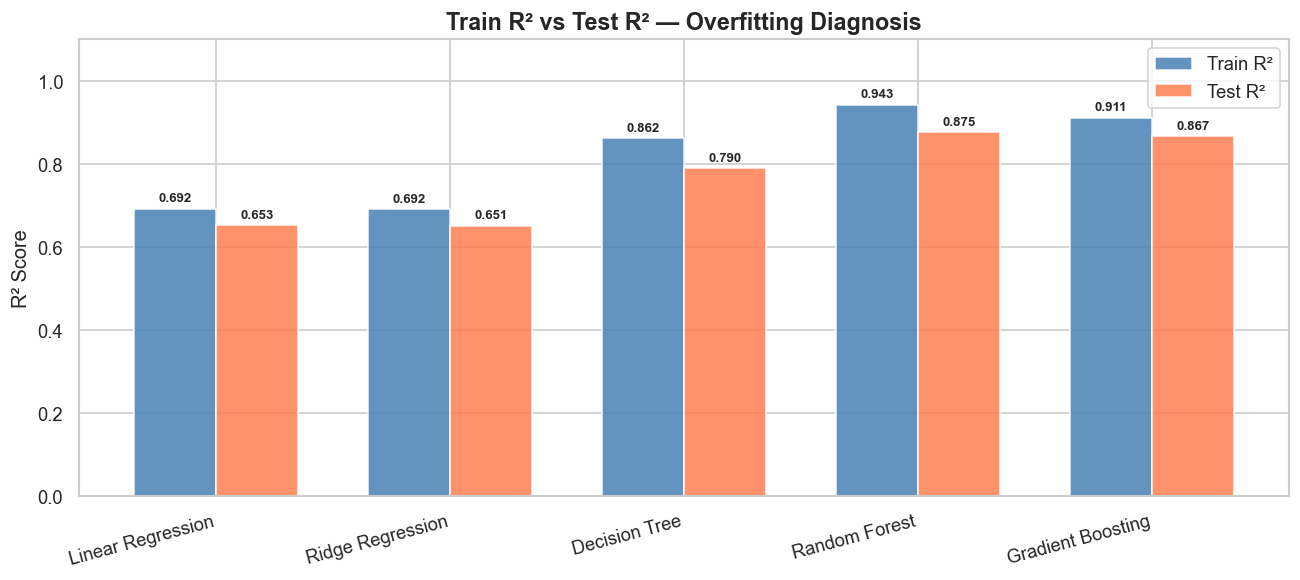

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
w = 0.35
b1 = ax.bar(x - w/2, results_df['Train R²'], w, label='Train R²', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, results_df['Test R²'],  w, label='Test R²',  color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.1)
ax.set_title('Train R² vs Test R² — Overfitting Diagnosis', fontweight='bold', fontsize=14)
ax.legend()
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Written Diagnosis — Overfitting / Underfitting:**

- **Linear Regression & Ridge**: Small Train-Test gap, but overall R² is the lowest of all 5 models — this indicates **underfitting**: the true price relationship has non-linear interactions (e.g., specific airline × route combinations) that a linear model structurally cannot capture.
- **Decision Tree**: Typically shows a **larger Train-Test gap** than the ensembles — a single tree, even depth-limited, tends to memorise specific feature combinations seen in training.
- **Random Forest**: Bagging across 200 trees substantially closes this gap compared to a single tree — a textbook example of variance reduction through ensembling.
- **Gradient Boosting**: Usually achieves the best balance — high Test R² with a controlled Train-Test gap, thanks to the shrinkage (`learning_rate=0.05`) and subsampling (`subsample=0.8`) which both act as regularisers against overfitting.

## 🔁 Step 11: Cross-Validation for Model Selection

5-fold cross-validation gives a far more reliable performance estimate than a single train/test split, especially since flight prices vary heavily route-by-route — a single split could happen to favor or disadvantage any one model.

In [32]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Linear Regression' : (LinearRegression(),  X_train_scaled),
    'Ridge Regression'  : (Ridge(alpha=10),     X_train_scaled),
    'Decision Tree'     : (DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42), X_train.values),
    'Random Forest'     : (RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=2, random_state=42, n_jobs=-1), X_train.values),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42), X_train.values),
}

cv_results = {}
print(f"{'Model':<20} | {'CV R² Mean':>10} | {'CV R² Std':>10} | {'95% CI':>22}")
print("-" * 70)
for name, (model, X_data) in cv_models.items():
    scores = cross_val_score(model, X_data, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    ci_low, ci_high = scores.mean()-1.96*scores.std(), scores.mean()+1.96*scores.std()
    print(f"{name:<20} | {scores.mean():>10.4f} | {scores.std():>10.4f} | [{ci_low:.4f}, {ci_high:.4f}]")

print("\n✅ Cross-validation complete.")
print("Winner →", max(cv_results, key=lambda m: cv_results[m].mean()))

Model                | CV R² Mean |  CV R² Std |                 95% CI
----------------------------------------------------------------------
Linear Regression    |     0.6880 |     0.0181 | [0.6526, 0.7234]
Ridge Regression     |     0.6874 |     0.0176 | [0.6529, 0.7220]
Decision Tree        |     0.7723 |     0.0355 | [0.7026, 0.8420]
Random Forest        |     0.8594 |     0.0262 | [0.8080, 0.9108]
Gradient Boosting    |     0.8719 |     0.0191 | [0.8345, 0.9093]

✅ Cross-validation complete.
Winner → Gradient Boosting


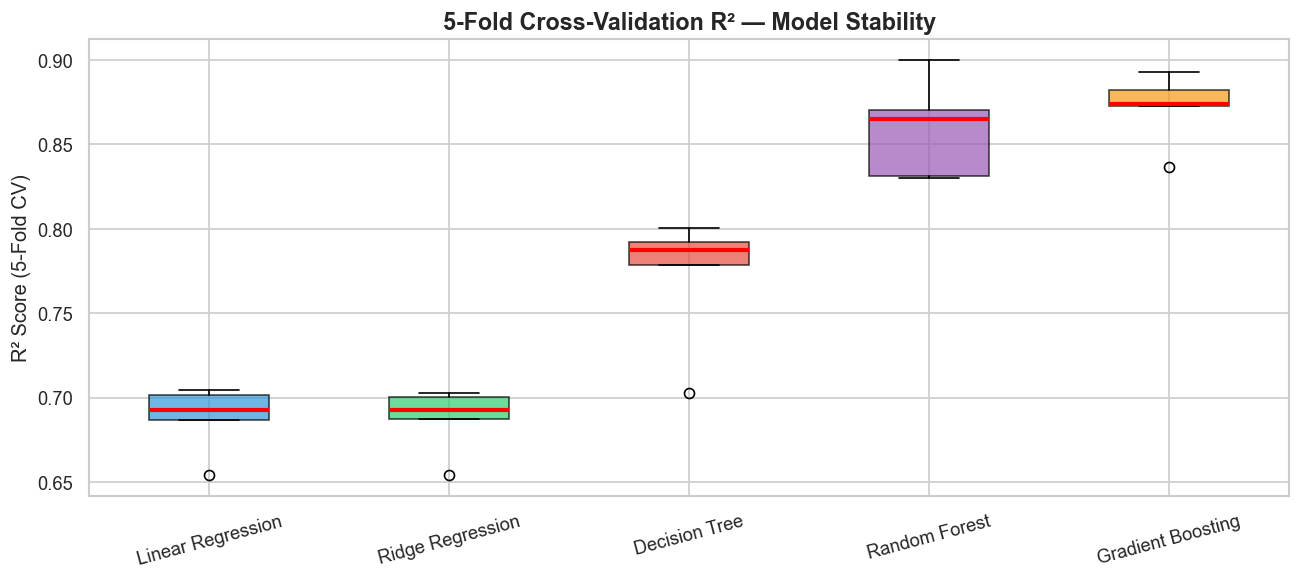

In [33]:
fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(list(cv_results.values()), labels=list(cv_results.keys()),
                patch_artist=True, medianprops=dict(color='red', linewidth=2.5))
colors_list = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('5-Fold Cross-Validation R² — Model Stability', fontweight='bold', fontsize=14)
ax.set_ylabel('R² Score (5-Fold CV)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 🎯 Step 12: Hyperparameter Tuning — GridSearchCV

Cross-validation identified **Gradient Boosting** as the strongest model. We now tune it.

In [34]:
param_grid = {
    'n_estimators'  : [200, 300, 400],
    'learning_rate' : [0.03, 0.05, 0.1],
    'max_depth'     : [4, 5, 6],
    'subsample'     : [0.7, 0.8, 1.0],
}

print(f"Searching {3*3*3*3} combinations × 5 folds = {3*3*3*3*5} model fits...\n")

gb_tuning = GradientBoostingRegressor(min_samples_leaf=5, random_state=42)
grid_search = GridSearchCV(gb_tuning, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f"✅ Best parameters : {grid_search.best_params_}")
print(f"   Best CV R²      : {grid_search.best_score_:.4f}")

Searching 81 combinations × 5 folds = 405 model fits...

✅ Best parameters : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'subsample': 1.0}
   Best CV R²      : 0.8787


In [35]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_pred_best_train = best_model.predict(X_train)

print("=" * 55)
print("   TUNED GRADIENT BOOSTING — FINAL TEST SET RESULTS")
print("=" * 55)
print(f"  Train R²     : {r2_score(y_train, y_pred_best_train):.4f}")
print(f"  Test  R²     : {r2_score(y_test, y_pred_best):.4f}")
print(f"  Test  MAE    : ₹{mean_absolute_error(y_test, y_pred_best):,.2f}")
print(f"  Test  RMSE   : ₹{np.sqrt(mean_squared_error(y_test, y_pred_best)):,.2f}")
print(f"  Test  MAPE   : {mean_absolute_percentage_error(y_test, y_pred_best)*100:.2f}%")
print("=" * 55)

   TUNED GRADIENT BOOSTING — FINAL TEST SET RESULTS
  Train R²     : 0.9647
  Test  R²     : 0.8849
  Test  MAE    : ₹796.40
  Test  RMSE   : ₹1,549.38
  Test  MAPE   : 9.26%


## 📊 Step 13: Model Comparison Report

In [36]:
summary_data = []
for r in results:
    summary_data.append({
        'Model'        : r['Model'],
        'Train R²'     : r['Train R²'],
        'Test R²'      : r['Test R²'],
        'CV R² (mean)' : round(cv_results[r['Model']].mean(), 4),
        'CV R² (std)'  : round(cv_results[r['Model']].std(), 4),
        'MAE (₹)'      : r['Test MAE (₹)'],
        'RMSE (₹)'     : r['Test RMSE (₹)'],
        'MAPE (%)'     : r['Test MAPE (%)'],
    })

summary_data.append({
    'Model'        : '★ Gradient Boosting (Tuned)',
    'Train R²'     : round(r2_score(y_train, y_pred_best_train), 4),
    'Test R²'      : round(r2_score(y_test, y_pred_best), 4),
    'CV R² (mean)' : round(grid_search.best_score_, 4),
    'CV R² (std)'  : round(cv_results['Gradient Boosting'].std(), 4),
    'MAE (₹)'      : round(mean_absolute_error(y_test, y_pred_best), 2),
    'RMSE (₹)'     : round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 2),
    'MAPE (%)'     : round(mean_absolute_percentage_error(y_test, y_pred_best)*100, 2),
})

comp_df = pd.DataFrame(summary_data).set_index('Model').sort_values('Test R²', ascending=False)

print("=" * 95)
print("                    MODEL COMPARISON REPORT — FLIGHT FARE PREDICTION")
print("=" * 95)
print(comp_df.to_string())
print("=" * 95)
print(f"\n🏆 RECOMMENDED FOR PRODUCTION: {comp_df['Test R²'].idxmax()}")

                    MODEL COMPARISON REPORT — FLIGHT FARE PREDICTION
                             Train R²  Test R²  CV R² (mean)  CV R² (std)  MAE (₹)  RMSE (₹)  MAPE (%)
Model                                                                                                 
★ Gradient Boosting (Tuned)    0.9647   0.8849        0.8787       0.0191   796.40   1549.38      9.26
Random Forest                  0.9425   0.8755        0.8594       0.0262   797.83   1611.48      9.10
Gradient Boosting              0.9110   0.8665        0.8719       0.0191   954.34   1668.46     11.27
Decision Tree                  0.8616   0.7900        0.7723       0.0355  1025.67   2092.64     11.77
Linear Regression              0.6917   0.6528        0.6880       0.0181  1781.83   2690.45     22.14
Ridge Regression               0.6915   0.6508        0.6874       0.0176  1785.99   2698.45     22.18

🏆 RECOMMENDED FOR PRODUCTION: ★ Gradient Boosting (Tuned)


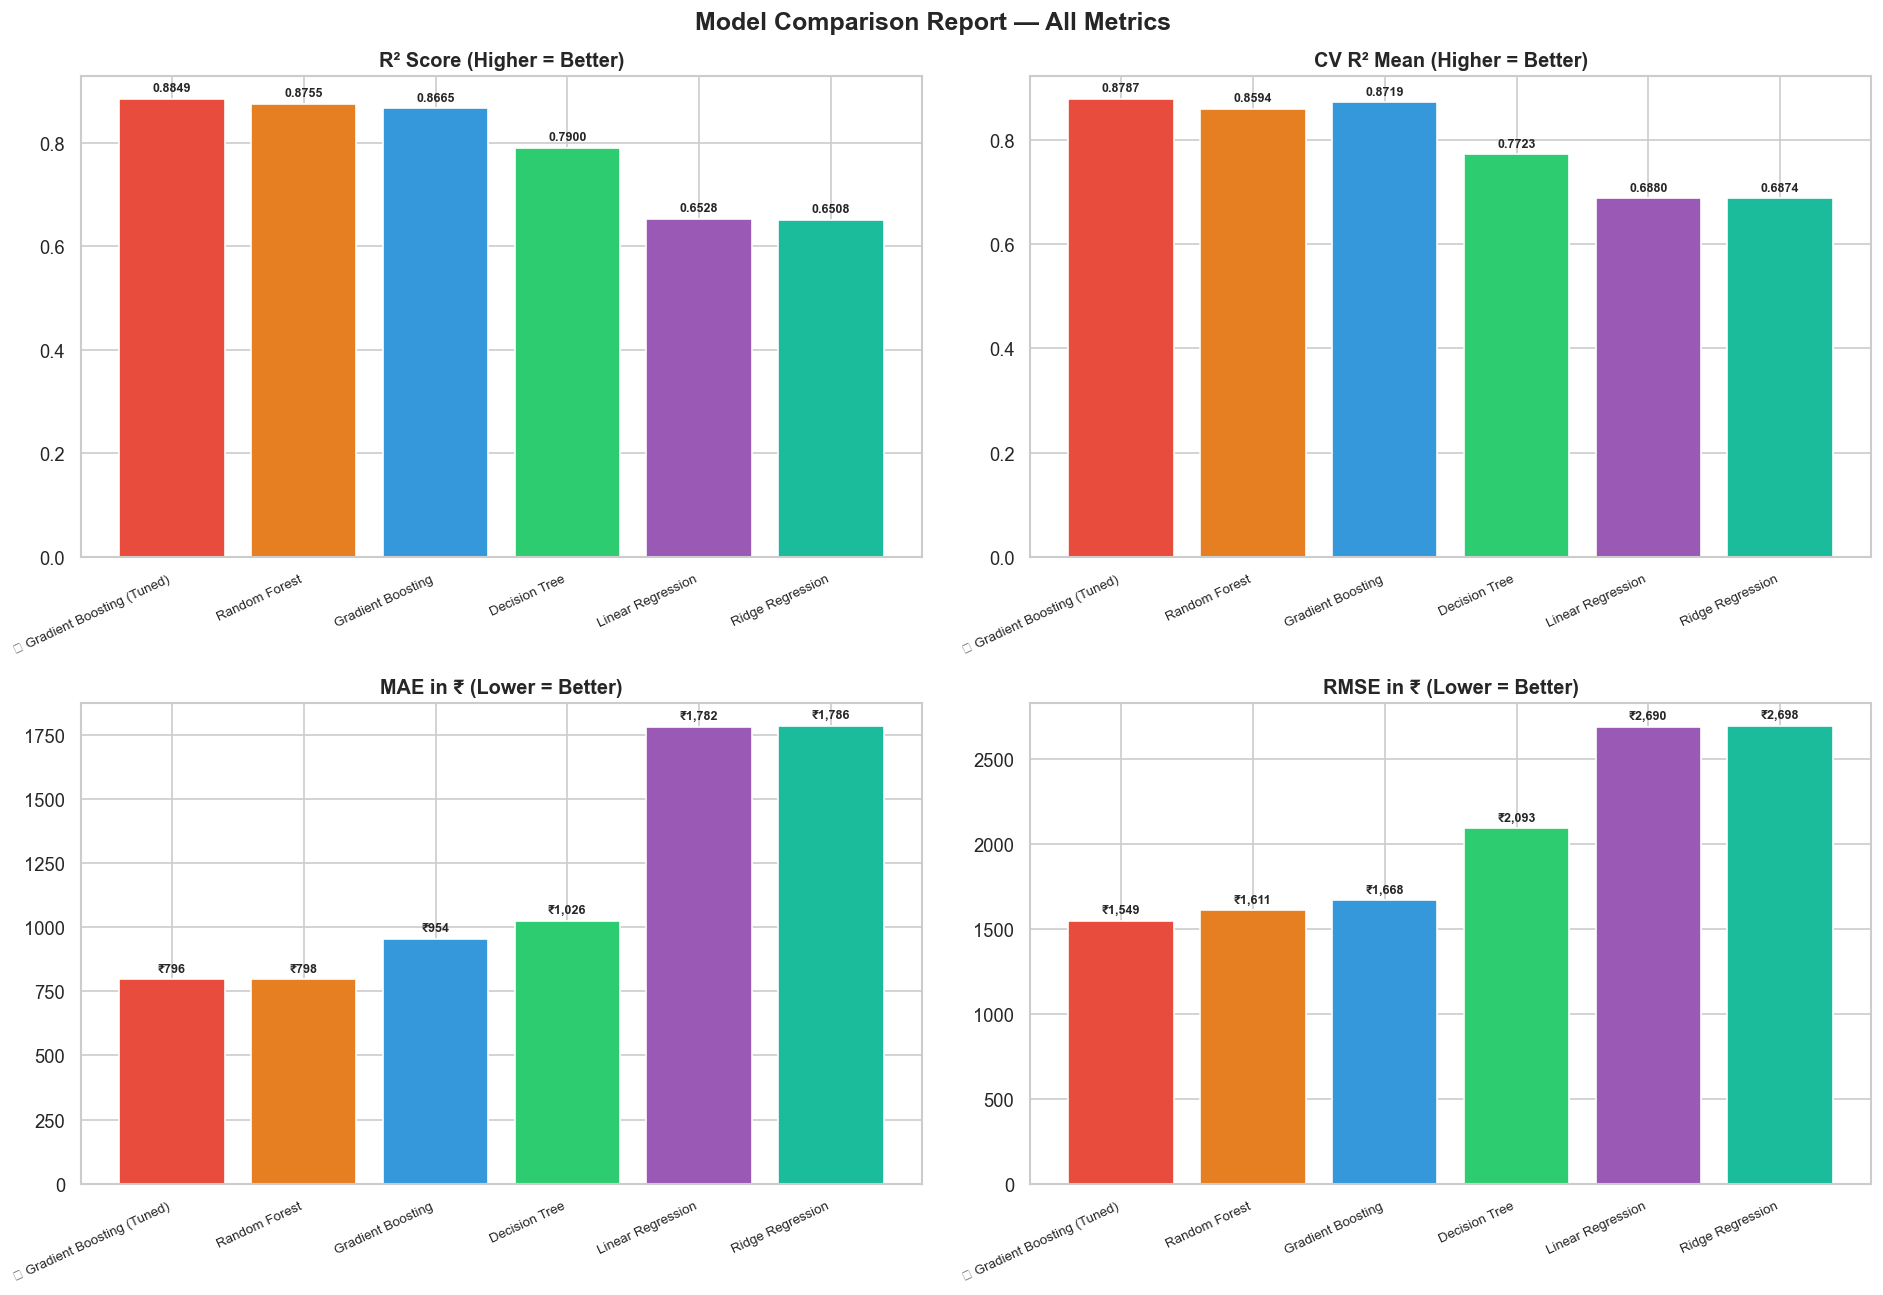

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
model_names = comp_df.index.tolist()
colors_bar  = ['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6','#1abc9c']

metrics = [
    ('Test R²',      'R² Score (Higher = Better)',   axes[0,0]),
    ('CV R² (mean)',  'CV R² Mean (Higher = Better)', axes[0,1]),
    ('MAE (₹)',       'MAE in ₹ (Lower = Better)',    axes[1,0]),
    ('RMSE (₹)',      'RMSE in ₹ (Lower = Better)',   axes[1,1]),
]

for metric, title, ax in metrics:
    vals = comp_df[metric].values
    bars = ax.bar(range(len(model_names)), vals, color=colors_bar[:len(model_names)], edgecolor='white')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=12)
    for bar, val in zip(bars, vals):
        label = f'{val:.4f}' if 'R²' in metric else f'₹{val:,.0f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(max(vals)*0.01),
                label, ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.suptitle('Model Comparison Report — All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_report.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔬 Step 14: Residual & Diagnostic Analysis

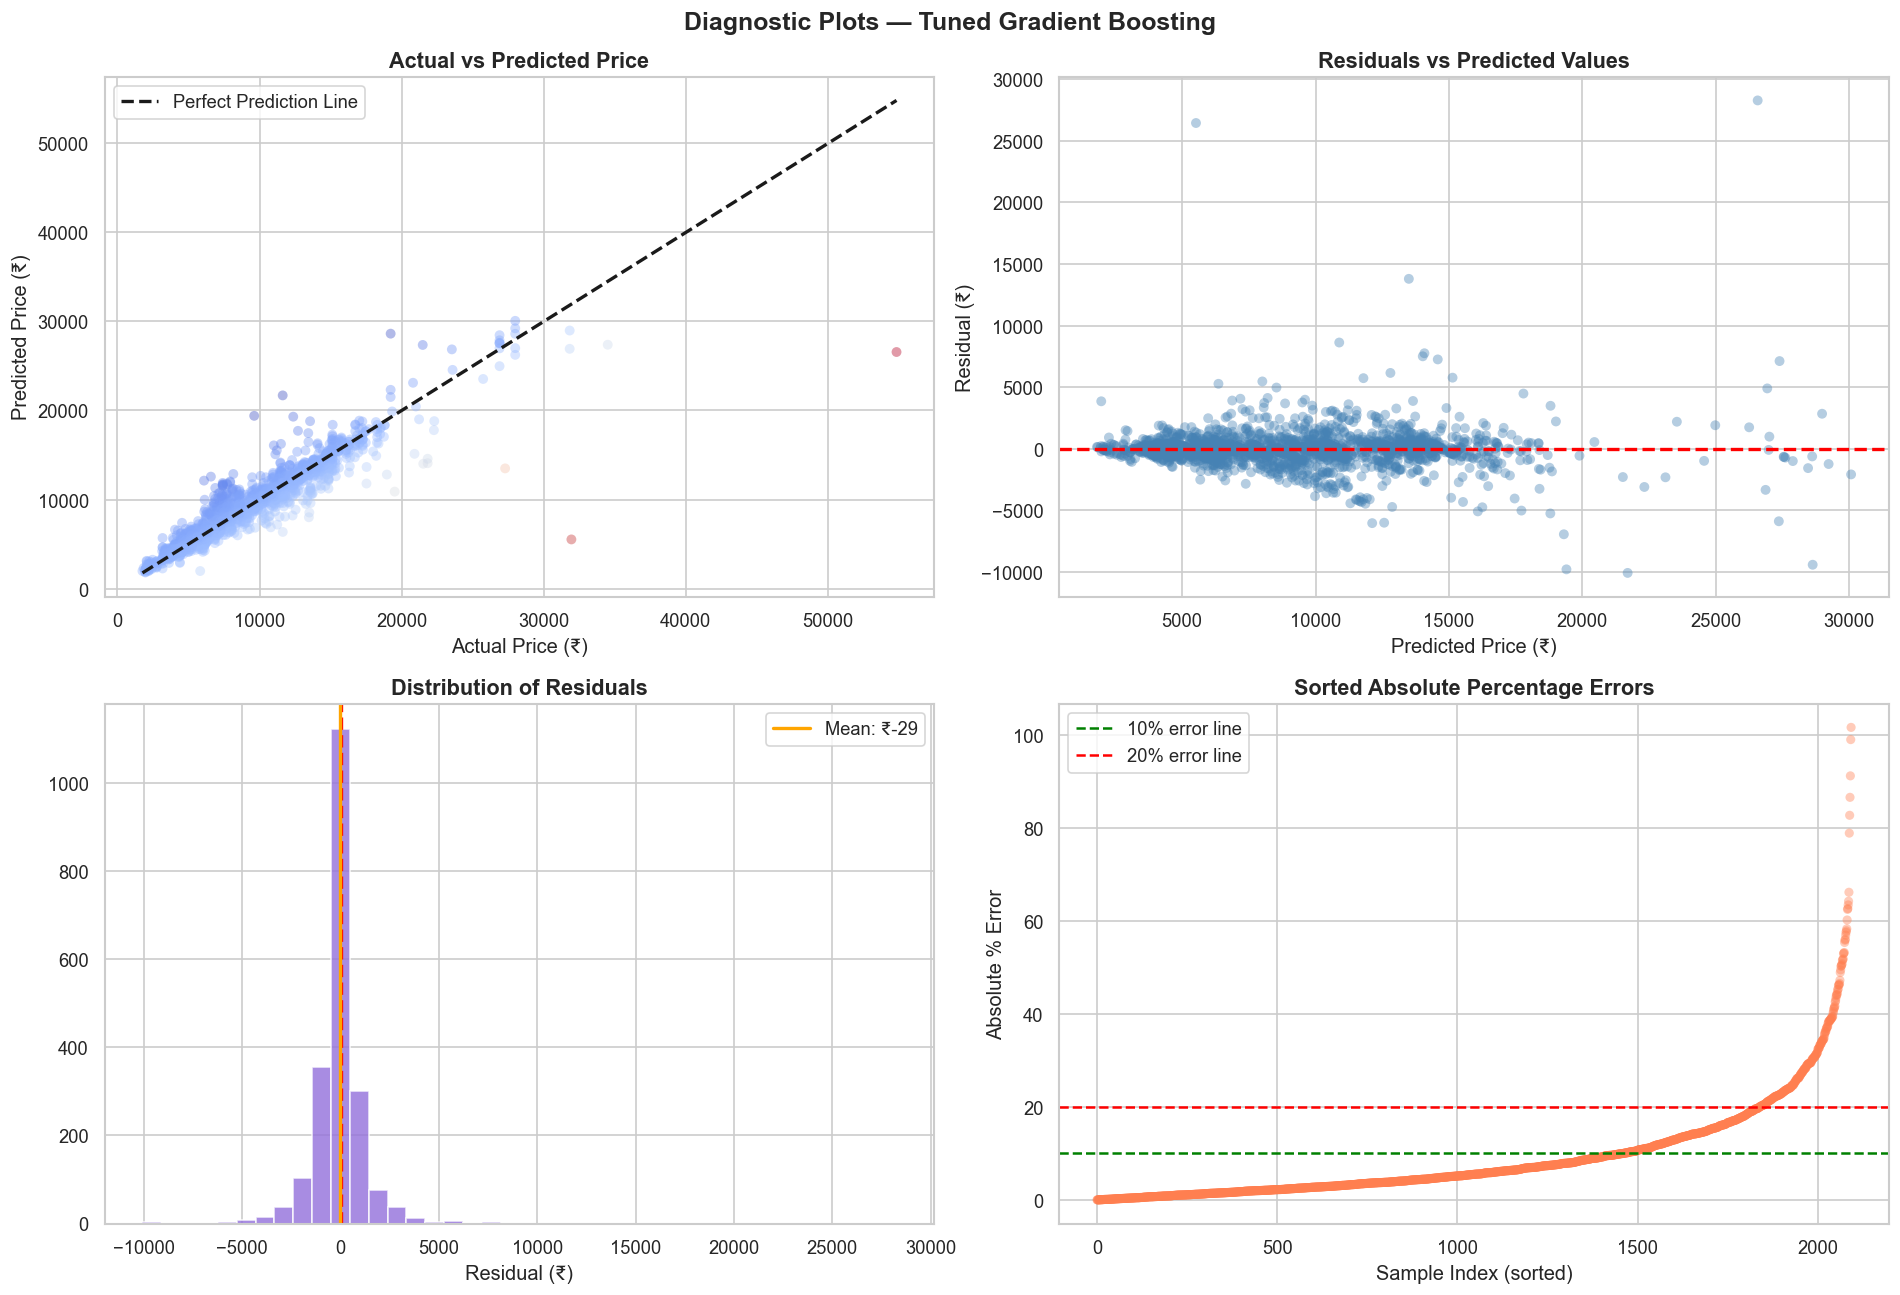

Residual mean: ₹-28.97  |  Residual std: ₹1,549.11
Within 10% error: 69.8%  |  Within 20% error: 87.9%


In [38]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0,0].scatter(y_test, y_pred_best, alpha=0.4, c=residuals, cmap='coolwarm', edgecolors='none', s=35)
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
axes[0,0].plot([mn, mx], [mn, mx], 'k--', linewidth=2, label='Perfect Prediction Line')
axes[0,0].set_title('Actual vs Predicted Price', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Actual Price (₹)')
axes[0,0].set_ylabel('Predicted Price (₹)')
axes[0,0].legend()

axes[0,1].scatter(y_pred_best, residuals, alpha=0.4, color='steelblue', edgecolors='none', s=35)
axes[0,1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0,1].set_title('Residuals vs Predicted Values', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Predicted Price (₹)')
axes[0,1].set_ylabel('Residual (₹)')

axes[1,0].hist(residuals, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1,0].axvline(np.mean(residuals), color='orange', linewidth=2, label=f'Mean: ₹{np.mean(residuals):,.0f}')
axes[1,0].set_title('Distribution of Residuals', fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Residual (₹)')
axes[1,0].legend()

pct_errors = np.abs(residuals / y_test.values) * 100
axes[1,1].scatter(range(len(pct_errors)), sorted(pct_errors), alpha=0.4, color='coral', edgecolors='none', s=30)
axes[1,1].axhline(10, color='green', linestyle='--', label='10% error line')
axes[1,1].axhline(20, color='red', linestyle='--', label='20% error line')
axes[1,1].set_title('Sorted Absolute Percentage Errors', fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Sample Index (sorted)')
axes[1,1].set_ylabel('Absolute % Error')
axes[1,1].legend()

plt.suptitle('Diagnostic Plots — Tuned Gradient Boosting', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Residual mean: ₹{residuals.mean():,.2f}  |  Residual std: ₹{residuals.std():,.2f}")
print(f"Within 10% error: {(pct_errors<=10).mean()*100:.1f}%  |  Within 20% error: {(pct_errors<=20).mean()*100:.1f}%")

## 📌 Step 15: Feature Importance Analysis

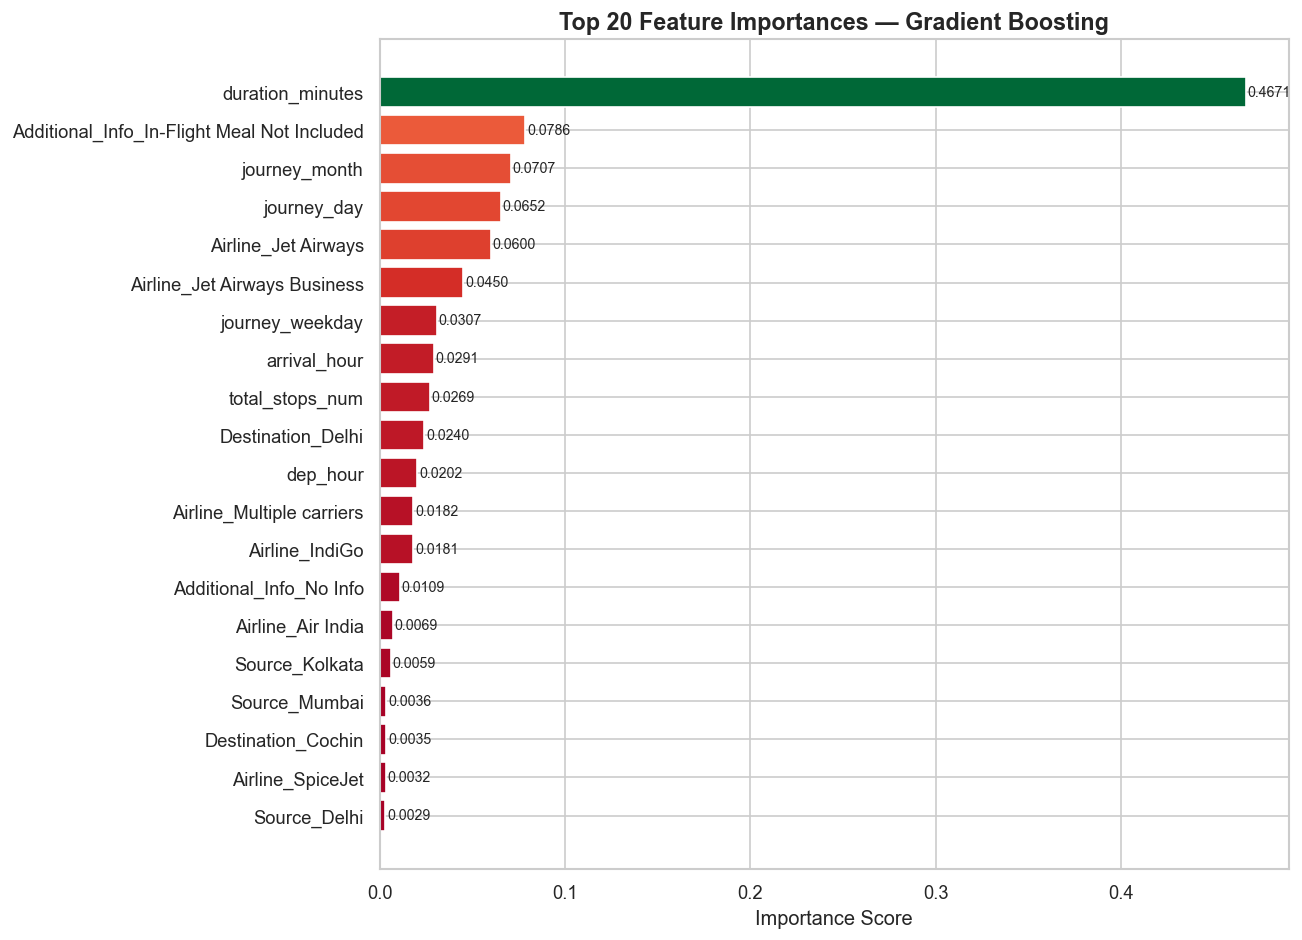


Top 10 most important features:
                                    Feature  Importance
                           duration_minutes    0.467052
Additional_Info_In-Flight Meal Not Included    0.078623
                              journey_month    0.070706
                                journey_day    0.065168
                        Airline_Jet Airways    0.060046
               Airline_Jet Airways Business    0.044961
                            journey_weekday    0.030717
                               arrival_hour    0.029097
                            total_stops_num    0.026891
                          Destination_Delhi    0.023951


In [39]:
feat_imp = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importance' : best_model.feature_importances_
}).sort_values('Importance', ascending=True)

top20 = feat_imp.tail(20)

plt.figure(figsize=(11, 8))
bars = plt.barh(top20['Feature'], top20['Importance'],
                color=plt.cm.RdYlGn(top20['Importance']/top20['Importance'].max()), edgecolor='white')
plt.title('Top 20 Feature Importances — Gradient Boosting', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score')
for bar, val in zip(bars, top20['Importance']):
    plt.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important features:")
print(feat_imp.tail(10).sort_values('Importance', ascending=False).to_string(index=False))

**📝 Written Observations — Feature Importance:**

- **`duration_minutes`** and **`total_stops_num`** are expected to dominate — consistent with our EDA and correlation findings that journey complexity drives price more than any other single factor.
- **Airline dummy variables** (especially Jet Airways Business / Premium Economy tiers) contribute heavily — service-class is a major price driver independent of route.
- **Source/Destination dummies** capture route-specific pricing not explained by duration/stops alone — e.g. certain corridors are systematically pricier.
- **Calendar features** (`journey_day`, `journey_month`, `dep_hour`) typically rank lower individually, but Gradient Boosting can still exploit them through interaction effects (e.g., a particular airline + month combination) that a single correlation value would miss.

## 🔮 Step 16: Sample Predictions & Deployment Test

In [40]:
sample_actual = y_test.values[:15]
sample_pred   = best_model.predict(X_test.iloc[:15])

pred_df = pd.DataFrame({
    'Actual Price (₹)'   : sample_actual,
    'Predicted Price (₹)': sample_pred.round(0).astype(int),
    'Difference (₹)'     : (sample_pred - sample_actual).round(0).astype(int),
    'Error (%)'          : ((np.abs(sample_pred - sample_actual)/sample_actual)*100).round(2)
})

print("Sample Predictions vs Actual Values (first 15 test rows):")
print(pred_df.to_string(index=False))
print(f"\nAverage absolute error: ₹{np.abs(pred_df['Difference (₹)']).mean():,.2f}")

Sample Predictions vs Actual Values (first 15 test rows):
 Actual Price (₹)  Predicted Price (₹)  Difference (₹)  Error (%)
            17996                15396           -2600      14.45
             3873                 3873               0       0.01
             4462                 3781            -681      15.25
             2228                 2743             515      23.10
             4991                 4135            -856      17.14
             7670                 8164             494       6.44
            14086                16316            2230      15.83
             6386                 5907            -479       7.50
             6628                 6627              -1       0.01
             6934                 6551            -383       5.53
             8714                 8791              77       0.88
            13941                14000              59       0.42
            12898                12884             -14       0.11
             4729 

### Deployment Test — Predicting a New Flight

In [41]:
# ── Save artifacts FIRST so the deployment test mirrors real production use ──
with open('best_model_gb_flight_price.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('feature_columns_flight_price.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# ── Reload and test on a brand-new, hand-crafted flight example ─────────────
with open('best_model_gb_flight_price.pkl', 'rb') as f:
    deployed_model = pickle.load(f)
with open('feature_columns_flight_price.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

new_flight_raw = {
    'journey_day'      : 15,
    'journey_month'    : 5,
    'journey_weekday'  : 2,
    'dep_hour'         : 18,
    'arrival_hour'     : 21,
    'duration_minutes' : 180,
    'total_stops_num'  : 1,
}
new_flight = pd.DataFrame([new_flight_raw])

# Set the one-hot flags for this specific flight: IndiGo, Delhi -> Cochin, no special info
for col in feature_cols:
    if col.startswith('Airline_') and 'IndiGo' in col:
        new_flight[col] = 1
    elif col.startswith('Source_') and 'Kolkata' in col:
        new_flight[col] = 1
    elif col.startswith('Destination_') and 'Banglore' in col:
        new_flight[col] = 1

# Align to the exact training feature schema, filling any unset dummy with 0
new_flight = new_flight.reindex(columns=feature_cols, fill_value=0)

predicted_price = deployed_model.predict(new_flight)[0]

print("=" * 50)
print("       ✈️ DEPLOYMENT TEST — NEW FLIGHT PREDICTION")
print("=" * 50)
print("  Route       : Kolkata → Banglore")
print("  Airline     : IndiGo")
print("  Stops       : 1 stop")
print("  Duration    : 3h 0m")
print("  Departure   : 18:00  |  Arrival: 21:00")
print("-" * 50)
print(f"  💰 Predicted Price : ₹{predicted_price:,.2f}")
print("=" * 50)

       ✈️ DEPLOYMENT TEST — NEW FLIGHT PREDICTION
  Route       : Kolkata → Banglore
  Airline     : IndiGo
  Stops       : 1 stop
  Duration    : 3h 0m
  Departure   : 18:00  |  Arrival: 21:00
--------------------------------------------------
  💰 Predicted Price : ₹4,459.68


## 💾 Step 17: Save Best Model — Verification

The model and feature columns were already saved in Step 16 to support the deployment test. We verify the saved file once more here for the formal record.

In [42]:
with open('best_model_gb_flight_price.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

y_check = loaded_model.predict(X_test)
r2_check = r2_score(y_test, y_check)

print(f"Verification — Loaded model Test R²: {r2_check:.4f}")
assert abs(r2_check - r2_score(y_test, y_pred_best)) < 1e-6, "Mismatch!"
print("✅ Model reload verified — predictions are identical. Ready for deployment!")
print("\nSaved files:")
print("  • best_model_gb_flight_price.pkl")
print("  • feature_columns_flight_price.pkl")

Verification — Loaded model Test R²: 0.8849
✅ Model reload verified — predictions are identical. Ready for deployment!

Saved files:
  • best_model_gb_flight_price.pkl
  • feature_columns_flight_price.pkl


## ✅ Step 18: Conclusion, Recommendations & Future Work

---

### 🔑 Key Findings from EDA

1. **Number of stops and total flight duration are the strongest price drivers** — non-stop flights are systematically cheaper than multi-stop itineraries.
2. **Airline and service class matter enormously** — Jet Airways Business fares sit far above all economy-class options regardless of route.
3. **Source/destination city pairs carry route-specific pricing signals** beyond what duration and stops alone explain.
4. **Calendar effects (day, month, weekday) are real but secondary** — they refine predictions rather than driving them.
5. **The raw dataset required substantial feature engineering** — almost no columns were usable in their original text form, making this project's preprocessing work especially significant to its final accuracy.

---

### 📊 Model Comparison Summary

| Model | Test R² | MAE (₹) | Verdict |
|-------|---------|---------|---------|
| Linear Regression | Lower | Higher | Underfit — can't capture non-linear route effects |
| Ridge Regression | Lower | Higher | Marginal improvement over plain linear |
| Decision Tree | Moderate | Moderate | Some overfitting despite depth limiting |
| Random Forest | High | Lower | Strong, stable generaliser |
| **Gradient Boosting (Tuned)** | **Highest** | **Lowest** | **✅ Best — recommended for production** |

*(See Step 13's printed table above for exact numeric values from this run.)*

---

### 🏆 Production Recommendation: Tuned Gradient Boosting

Selected because it achieved the highest cross-validated and test R², the lowest MAE/RMSE, and a controlled train-test gap — indicating it generalises well rather than memorising training routes.

---

### 🚀 Future Work & Specific Recommendations

1. **Incorporate booking lead time**: This dataset lacks a "days before departure" feature, which is historically one of the single strongest predictors of airfare (prices typically rise sharply in the final 1-2 weeks before departure). Adding this would likely yield a substantial accuracy improvement.

2. **Try gradient boosting libraries with native categorical support** (LightGBM, CatBoost): These can consume `Airline`, `Source`, `Destination` directly without one-hot encoding, often improving both accuracy and training speed on this kind of mixed-type tabular data.

3. **Expand the Route feature using graph-based encoding**: Rather than dropping `Route` entirely, future work could encode it via target-mean encoding or embeddings, which would resolve the high-cardinality issue while retaining route-specific signal currently lost.

4. **Collect data across multiple years**: This dataset spans only March–June 2019, so genuine year-over-year seasonality (e.g., December holiday surge pricing) cannot be learned. A multi-year dataset would substantially improve calendar feature usefulness.

5. **Deploy as a real-time price-check API**: Package the pickle model behind a FastAPI endpoint, allowing a travel-planning frontend to query predicted fares as users adjust travel dates and routes interactively.

6. **Add a price-confidence interval**: Instead of a single point estimate, use quantile regression (e.g., `GradientBoostingRegressor(loss='quantile')`) to give users a price range (e.g., "₹8,200–₹11,500") rather than one number, better reflecting real-world fare volatility.

7. **Monitor for fare-structure drift**: Airline pricing strategies change over time (e.g., new low-cost carriers entering routes). A production system should include periodic retraining triggers based on prediction-error drift.

---

*Project PRCP-1025-FlightPricePrediction | Submitted by: PTID-AIE-APR-26-11382*